# Restaurant Business Analysis

This notebook explores restaurant sales data to identify key trends in revenue, product performance, and profitability.

The goal is to generate insights that can support business decisions and improve overall performance.

## Data Loading

In this step, we load the datasets required for analysis, including orders and order item details.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv('../data/orders.csv')
order_items = pd.read_csv('../data/order_items.csv')

## Monthly Revenue Analysis

This analysis examines how revenue changes over time.

Understanding monthly trends helps identify seasonality patterns, growth opportunities, and periods of low performance.

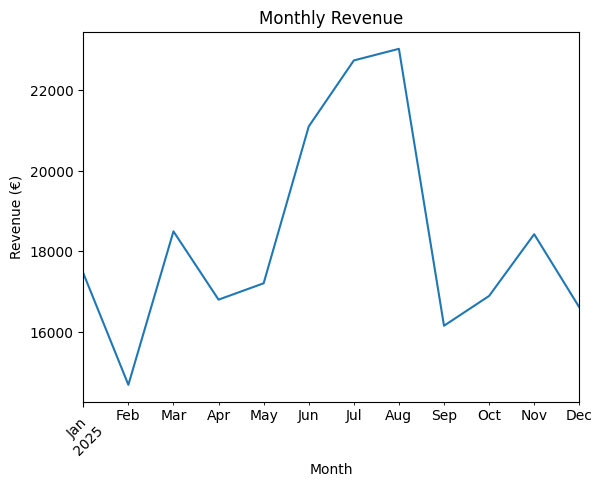

In [9]:
orders['order_date'] = pd.to_datetime(orders['order_date'])

monthly = orders[orders['status'] == 'Completed'] \
    .groupby(orders['order_date'].dt.to_period('M'))['total_revenue_eur'] \
    .sum()

monthly.plot(kind='line')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (€)')
plt.xticks(rotation=45)

plt.savefig('../images/monthly_revenue.png')

plt.show()

### Insights

- Revenue shows a drop in February, likely due to seasonal factors  
- A strong recovery is observed in March  
- Revenue peaks in June, indicating increased summer demand  
- Overall trend suggests gradual business growth over time  

## Top-Selling Products

This section identifies which products are sold the most and highlights customer preferences.

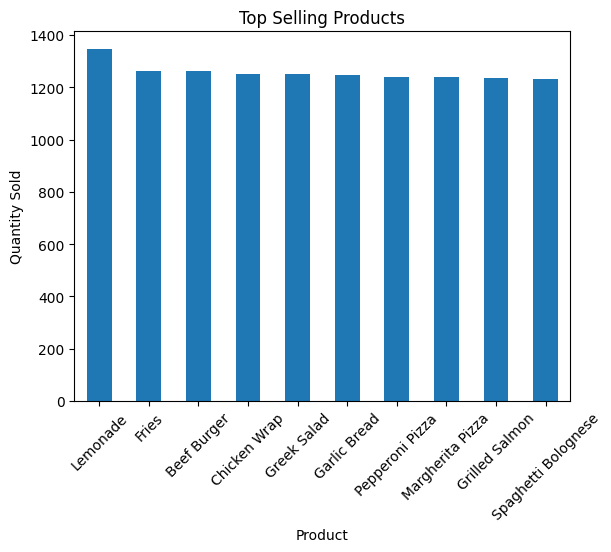

In [10]:
top_products = (
    order_items.groupby('item_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='bar')
plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)

plt.savefig('../images/top_products.png')
plt.show()

### Insights

Lemonade is the most sold product, showing strong demand for beverages.  
Fries are a popular side item that increases order value.  
Chicken Wrap is the most popular main dish.  
Sales across categories suggest strong cross-selling opportunities.

## Profitability by Category

This section focuses on identifying which categories generate the most profit.

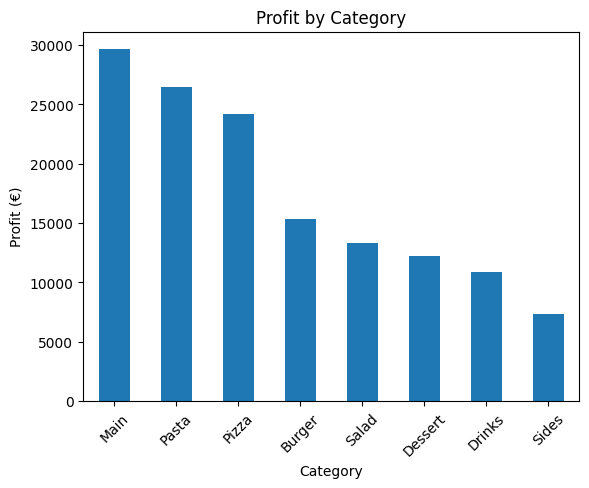

In [11]:
profit = (
    order_items.groupby('category')['line_profit_eur']
    .sum()
    .sort_values(ascending=False)
)

profit.plot(kind='bar')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit (€)')
plt.xticks(rotation=45)

plt.savefig('../images/profit_by_category.png')
plt.show()

### Insights

Main dishes generate the highest profit.  
Pasta and Pizza are also strong contributors.  
Drinks and sides have high sales volume but lower profit margins.  
Focusing on high-margin items can improve profitability.

## Conclusion

Revenue shows seasonal trends with strong summer performance.  
Customer demand is highest during dinner hours.  
High-margin items such as main dishes drive profitability.  
Data analysis can help improve pricing, promotions, and menu strategy.